In [53]:
# ==============================
# STEP 1 — IMPORT LIBRARIES
# ==============================

import os
import copy
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix


In [54]:
# STEP 2 — CHECK DEVICE (CUDA)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {device}")

Using Device: cuda


In [55]:
# STEP 3 — DEFINE HYPERPARAMETERS
# ==============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nHyperparameters Loaded Successfully")


Hyperparameters Loaded Successfully


In [56]:
# STEP 4 — DEFINE TRANSFORMATIONS
# ==============================

train_transforms = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transforms = transforms.Compose([
    
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [1]:
# STEP 5 — LOAD DATASETS
# ==============================
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/prasadvpatil/mrl-dataset/train",
    transform=transform
)


NameError: name 'transform' is not defined

In [58]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

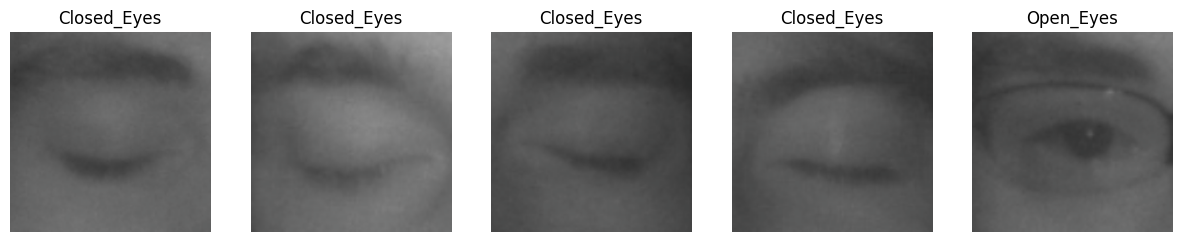

In [59]:
# STEP 7 — VISUALIZE SAMPLE IMAGES
# ==============================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    
    image = images[i].permute(1, 2, 0).numpy()
    
    # Unnormalize image for display
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    
    image = np.clip(image, 0, 1)

    axes[i].imshow(image)
    axes[i].set_title(CLASS_NAMES[labels[i]])
    axes[i].axis("off")

plt.show()



In [60]:
# STEP 8 — LOAD MOBILENETV2
# ==============================

model = models.mobilenet_v2(pretrained=True)



# ==============================
# STEP 9 — FREEZE BASE LAYERS
# ==============================

for param in model.parameters():
    param.requires_grad = False


In [61]:

model.classifier = nn.Sequential(
    
    nn.Dropout(0.3),
    
    nn.Linear(model.last_channel, NUM_CLASSES)
)



# MOVE MODEL TO DEVICE
model = model.to(device)


print("MobileNetV2 Model Loaded Successfully")

MobileNetV2 Model Loaded Successfully


In [62]:
# ==============================
# STEP 10 — DEFINE LOSS FUNCTION
# ==============================

criterion = nn.CrossEntropyLoss()



# ==============================
# STEP 11 — DEFINE OPTIMIZER
# ==============================

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

In [63]:
# STEP 12 — TRAIN FUNCTION
# ==============================

def train_model(model, loader):
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy




In [64]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

In [66]:
# STEP 14 — TRAINING LOOP
# ==============================

best_accuracy = 0.0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 30)

    
    # TRAINING
    train_loss, train_acc = train_model(model, train_loader)

    
    # VALIDATION
    val_loss, val_acc = validate_model(model, val_loader)

    # STORE HISTORY
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    # PRINT RESULTS
    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.2f}%")

    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_acc:.2f}%")




Epoch [1/15]
------------------------------
Train Loss     : 0.2930
Train Accuracy : 93.91%
Val Loss       : 0.2147
Val Accuracy   : 98.12%

Epoch [2/15]
------------------------------
Train Loss     : 0.2140
Train Accuracy : 95.88%
Val Loss       : 0.1576
Val Accuracy   : 98.75%

Epoch [3/15]
------------------------------
Train Loss     : 0.1680
Train Accuracy : 96.91%
Val Loss       : 0.1257
Val Accuracy   : 98.88%

Epoch [4/15]
------------------------------
Train Loss     : 0.1434
Train Accuracy : 97.47%
Val Loss       : 0.1059
Val Accuracy   : 99.00%

Epoch [5/15]
------------------------------
Train Loss     : 0.1250
Train Accuracy : 97.66%
Val Loss       : 0.0909
Val Accuracy   : 99.00%

Epoch [6/15]
------------------------------
Train Loss     : 0.1152
Train Accuracy : 97.34%
Val Loss       : 0.0860
Val Accuracy   : 99.00%

Epoch [7/15]
------------------------------
Train Loss     : 0.1003
Train Accuracy : 97.94%
Val Loss       : 0.0709
Val Accuracy   : 99.12%

Epoch [8/15]

In [68]:
# STEP 15 — SAVE BEST MODEL
    # ==============================

if val_acc > best_accuracy:
    best_accuracy = val_acc

    torch.save(model.state_dict(), "best_mobilenetv2_model.pth")

    print("✅ Best Model Saved!")


print("\nTraining Completed Successfully!")
print(f"Best Validation Accuracy: {best_accuracy:.2f}%")


Training Completed Successfully!
Best Validation Accuracy: 99.62%


In [71]:
# STEP 16 — LOAD BEST MODEL
# ==============================

model.load_state_dict(torch.load("best_mobilenetv2_model.pth"))

model.eval()

print("Best Model Loaded Successfully!")



Best Model Loaded Successfully!


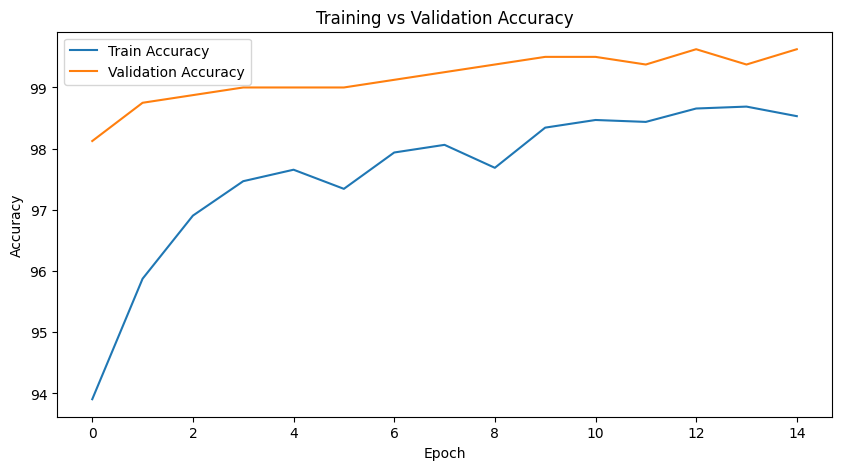

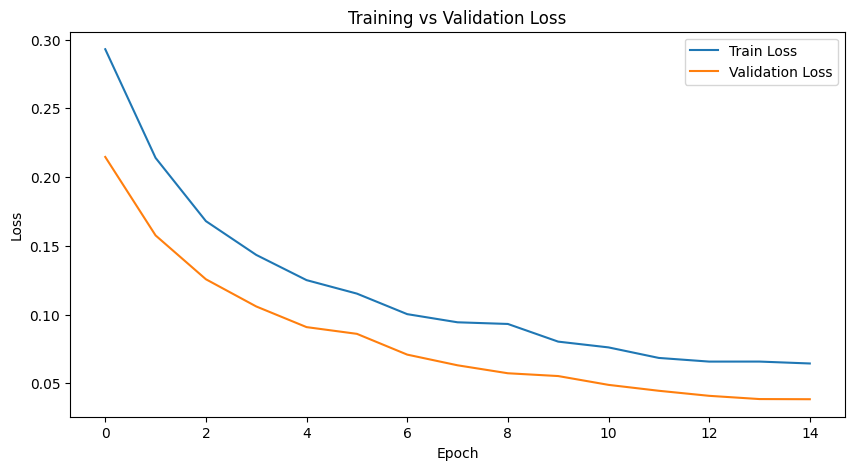

In [72]:
# STEP 17 — PLOT ACCURACY & LOSS
# ==============================

# Accuracy Graph
plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()



# Loss Graph
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()



In [74]:
# STEP 18 — CONFUSION MATRIX
# ==============================

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES
))


# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:\n")
print(cm)


Classification Report:

              precision    recall  f1-score   support

 Closed_Eyes       0.99      1.00      1.00       378
   Open_Eyes       1.00      1.00      1.00       422

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Confusion Matrix:

[[377   1]
 [  2 420]]


In [75]:
# Save Final Model

torch.save(model.state_dict(), "driver_drowsiness_mobilenetv2.pth")

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


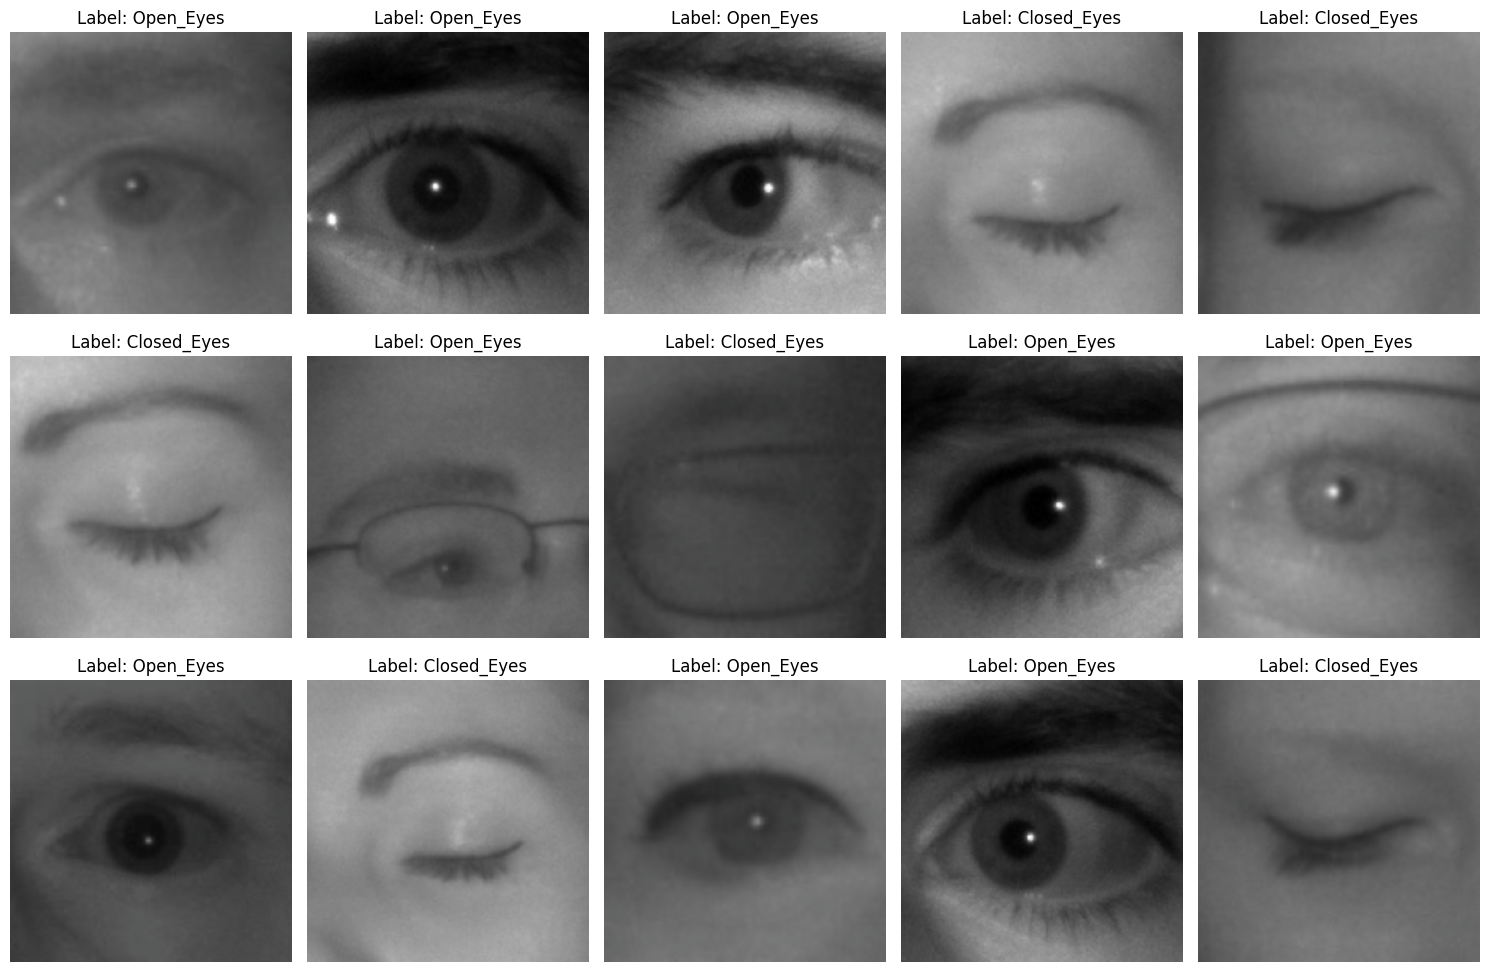

In [76]:
import matplotlib.pyplot as plt
import random

# Random samples
fig, axes = plt.subplots(3, 5, figsize=(15,10))

for i, ax in enumerate(axes.flat):

    random_index = random.randint(0, len(train_dataset)-1)

    image, label = train_dataset[random_index]

    # Convert tensor to image
    image = image.permute(1, 2, 0).numpy()

    # Unnormalize
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

    image = np.clip(image, 0, 1)

    ax.imshow(image)

    ax.set_title(f"Label: {train_dataset.classes[label]}")

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import json
import os

def count_notebook_loc(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        nb = json.load(f)
        
    total_loc = 0
    for cell in nb['cells']:
        if cell['cell_type'] == 'code':
            # Filter out empty lines or comments if you want strict LOC
            lines = [line for line in cell['source'] if line.strip() and not line.strip().startswith('#')]
            total_loc += len(lines)
    return total_loc

# Note: In Kaggle, the current notebook is usually saved as '__main__.ipynb' during execution
# or you can point it to a specific file in /kaggle/working
print(f"Total Code Lines: {count_notebook_loc('DDD-MobileNetV2-version.ipynb')}")